# Breast Cancer Wisconsin

The Breast Cancer Wisconsin Dataset is a foundational collection from the UCI Machine Learning Repository, used extensively in medical and machine learning research for tumor classification. It includes digitized measurements from breast mass samples to distinguish malignant from benign cases, underpinning countless studies in diagnostic modeling and feature analysis.

In [98]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf

## Import the data

In [99]:
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)
df = pd.read_csv(f'{path}/data.csv')

Path to dataset files: C:\Users\user-pc\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


## Cleaning The Data

In [100]:
df = df.drop(columns=['id', 'Unnamed: 32'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df.drop(columns=['diagnosis']).to_numpy()
y = df['diagnosis'].to_numpy()
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (569, 30)
Shape of y: (569,)


## Splitting the Data

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)

Training set shape: (364, 30) (364,)
Validation set shape: (91, 30) (91,)


## Data Normalization

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Configure The Model

In [103]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(128, activation='relu', input_shape=(30,)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
  loss='binary_crossentropy',
  metrics=['accuracy'])

c:\Projects\tjabane.thuto.deep-learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [104]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))
validation_loss, validation_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {validation_loss:.4f}, Test Accuracy: {validation_accuracy:.4f}")

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9231 - loss: 0.2014 - val_accuracy: 0.9670 - val_loss: 0.1949
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0683 - val_accuracy: 0.9670 - val_loss: 0.2751
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9835 - loss: 0.0362 - val_accuracy: 0.9670 - val_loss: 0.1835
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - loss: 0.0255 - val_accuracy: 0.9670 - val_loss: 0.2560
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9945 - loss: 0.0115 - val_accuracy: 0.9670 - val_loss: 0.3080
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9670 - val_loss: 0.3077
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9670 - val_loss: 0.3148
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9670 - val_loss

## Training Metrics

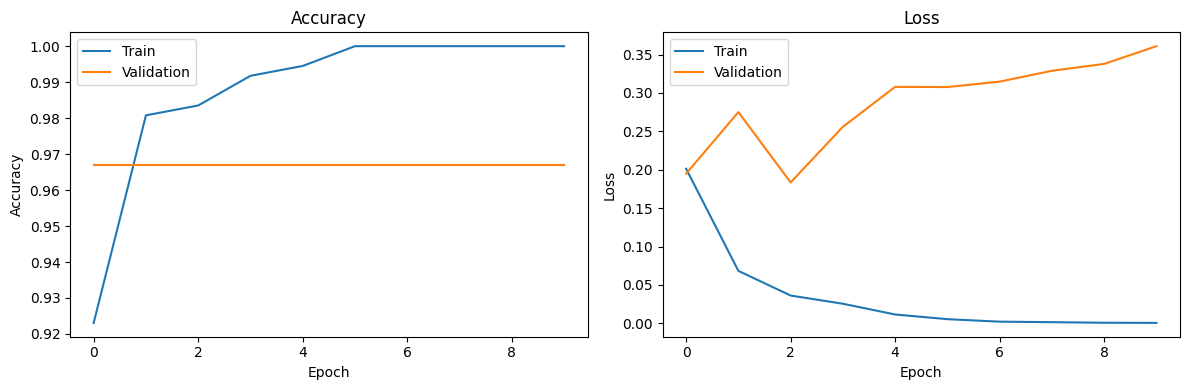

In [105]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()